# 04 - Estrategia de quiniela y resultados de la simulación

Lee los outputs del pipeline:
- `outputs/picks/quiniela_*.csv` (4 perfiles de riesgo)
- `outputs/simulations/*` (probabilidades agregadas Monte-Carlo)

Visualiza el bracket esperado, compara picks entre perfiles, y muestra los favoritos al título.

**Prerequisito**: haber corrido `export_quiniela_sheet.py` y `simulate_tournament.py`.

In [1]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

OUTPUTS = ROOT / 'outputs'
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

## Carga de las 4 quinielas

In [2]:
PROFILES = ['safe', 'balanced', 'aggressive', 'contrarian']
sheets = {p: pd.read_csv(OUTPUTS / 'picks' / f'quiniela_{p}.csv') for p in PROFILES}

for p, df in sheets.items():
    print(f'{p:12s}: {len(df)} picks  | distribución: {df["pick"].value_counts().to_dict()}  | confianza media: {df["confidence"].mean():.3f}')

safe        : 72 picks  | distribución: {'H': 44, 'A': 28}  | confianza media: 0.590
balanced    : 72 picks  | distribución: {'H': 28, 'D': 22, 'A': 22}  | confianza media: 0.527
aggressive  : 72 picks  | distribución: {'H': 38, 'A': 34}  | confianza media: 0.496
contrarian  : 72 picks  | distribución: {'A': 38, 'H': 34}  | confianza media: 0.181


## Comparación de picks por partido entre los 4 perfiles

Muestra los partidos donde los perfiles **difieren** — son los que tienen mayor valor estratégico.

In [3]:
merge_cols = ['team_a', 'team_b']
base = sheets['balanced'][merge_cols + ['p_home', 'p_draw', 'p_away']].copy()
for p in PROFILES:
    base[f'pick_{p}'] = sheets[p]['pick'].values

different = base[
    (base['pick_safe'] != base['pick_balanced'])
    | (base['pick_balanced'] != base['pick_aggressive'])
    | (base['pick_aggressive'] != base['pick_contrarian'])
]
print(f'Partidos donde difieren los perfiles: {len(different)} / {len(base)}')
print()
print(different.head(20).to_string(index=False))

Partidos donde difieren los perfiles: 71 / 72

       team_a             team_b   p_home   p_draw   p_away pick_safe pick_balanced pick_aggressive pick_contrarian
       Mexico       South Africa 0.557126 0.320905 0.121968         H             H               H               A
  South Korea            Czechia 0.733855 0.227006 0.039139         H             H               H               A
       Canada Bosnia-Herzegovina 0.733855 0.227006 0.039139         H             H               H               A
United States           Paraguay 0.485995 0.279934 0.234071         H             D               A               A
        Qatar        Switzerland 0.132044 0.127030 0.740927         A             A               A               H
       Brazil            Morocco 0.410590 0.285695 0.303715         H             D               A               A
    Australia             Turkey 0.456969 0.263214 0.279817         H             H               A               A
  Netherlands            

## Confianza promedio por perfil

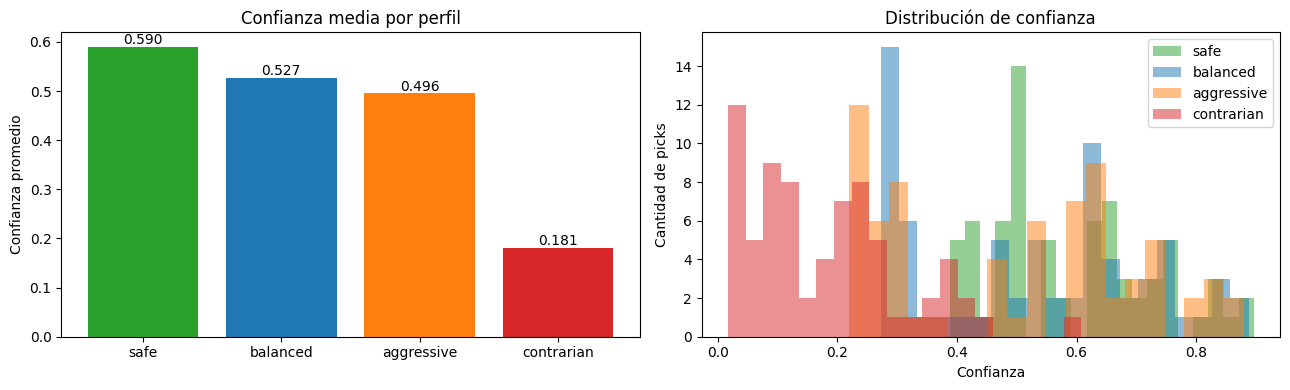

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

means = [sheets[p]['confidence'].mean() for p in PROFILES]
axes[0].bar(PROFILES, means, color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'])
axes[0].set_ylabel('Confianza promedio')
axes[0].set_title('Confianza media por perfil')
for i, m in enumerate(means):
    axes[0].text(i, m + 0.005, f'{m:.3f}', ha='center')

for p, c in zip(PROFILES, ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']):
    axes[1].hist(sheets[p]['confidence'], bins=20, alpha=0.5, label=p, color=c)
axes[1].set_xlabel('Confianza')
axes[1].set_ylabel('Cantidad de picks')
axes[1].set_title('Distribución de confianza')
axes[1].legend()

plt.tight_layout()
plt.show()

## Probabilidades de clasificación a octavos

In [5]:
qual = pd.read_csv(OUTPUTS / 'simulations' / 'tournament_probabilities.csv')
print(f'Total equipos: {len(qual)}')
print()
print('Top 20 con mayor prob de clasificación:')
print(qual.head(20).to_string(index=False))
print()
print('Bottom 10:')
print(qual.tail(10).to_string(index=False))

Total equipos: 48

Top 20 con mayor prob de clasificación:
       team  qualification_prob
      Spain              0.9805
    England              0.9305
   Portugal              0.9205
  Argentina              0.8915
     Mexico              0.8830
    Belgium              0.8775
Switzerland              0.8755
     France              0.8695
    Germany              0.8455
   Colombia              0.8405
     Canada              0.8370
    Morocco              0.8265
      Japan              0.8230
     Brazil              0.8195
Netherlands              0.8180
South Korea              0.8030
    Uruguay              0.7995
    Algeria              0.7800
  Australia              0.7675
     Norway              0.7405

Bottom 10:
              team  qualification_prob
      Saudi Arabia              0.4910
             Ghana              0.4630
           Curaçao              0.4505
Bosnia-Herzegovina              0.4155
       New Zealand              0.3835
              Iraq     

## Favoritos al título

Total equipos con prob > 0: 44
Suma de probabilidades: 1.0000 (debe ≈ 1.0)

       team  championship_prob
      Spain             0.1260
  Argentina             0.0980
    England             0.0930
     France             0.0630
     Brazil             0.0455
      Japan             0.0440
   Portugal             0.0440
    Morocco             0.0425
Netherlands             0.0420
    Germany             0.0395
   Colombia             0.0270
    Belgium             0.0265
     Norway             0.0235
  Australia             0.0220
    Uruguay             0.0220
Switzerland             0.0215
    Senegal             0.0200
     Mexico             0.0190
    Algeria             0.0190
     Turkey             0.0165


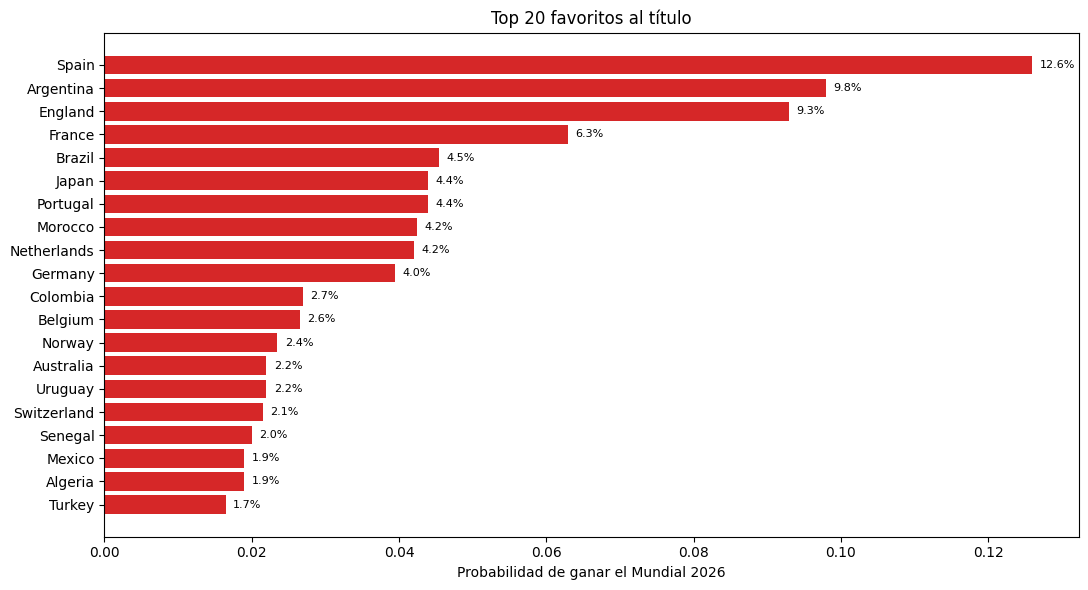

In [6]:
champ = pd.read_csv(OUTPUTS / 'simulations' / 'championship_probabilities.csv')
print(f'Total equipos con prob > 0: {(champ["championship_prob"] > 0).sum()}')
print(f'Suma de probabilidades: {champ["championship_prob"].sum():.4f} (debe ≈ 1.0)')
print()
top20 = champ.head(20)
print(top20.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top20['team'][::-1], top20['championship_prob'][::-1], color='#d62728')
ax.set_xlabel('Probabilidad de ganar el Mundial 2026')
ax.set_title('Top 20 favoritos al título')
for i, v in enumerate(top20['championship_prob'][::-1]):
    ax.text(v + 0.001, i, f'{v*100:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## Probabilidad de llegar a cada ronda (top 15)

Top 15 favoritos - prob de llegar a cada ronda:
             Octavos  8vos  Cuartos  Semis  Final  Campeón
team                                                      
Spain           35.9  19.7     13.7    8.8    7.4     12.6
Argentina       30.8  21.0     13.4    9.2    5.0      9.8
England         28.2  20.0     19.0   10.0    6.6      9.3
France          36.0  20.8     12.2    7.0    4.6      6.3
Brazil          30.1  19.3     14.0    8.8    5.1      4.6
Japan           34.1  20.3     13.7    5.7    4.1      4.4
Portugal        39.7  23.1     14.1    6.7    4.0      4.4
Morocco         31.2  18.8     14.4    9.4    4.6      4.2
Netherlands     31.4  21.4     14.9    6.2    3.7      4.2
Germany         34.8  22.0     12.6    7.2    4.2      4.0
Colombia        39.8  21.3     12.2    5.2    2.8      2.7
Belgium         38.4  25.8     12.2    5.5    3.2      2.6
Norway          38.2  17.4      9.2    4.6    2.4      2.4
Australia       38.4  18.8      8.6    6.2    2.6      2.2
Uruguay 

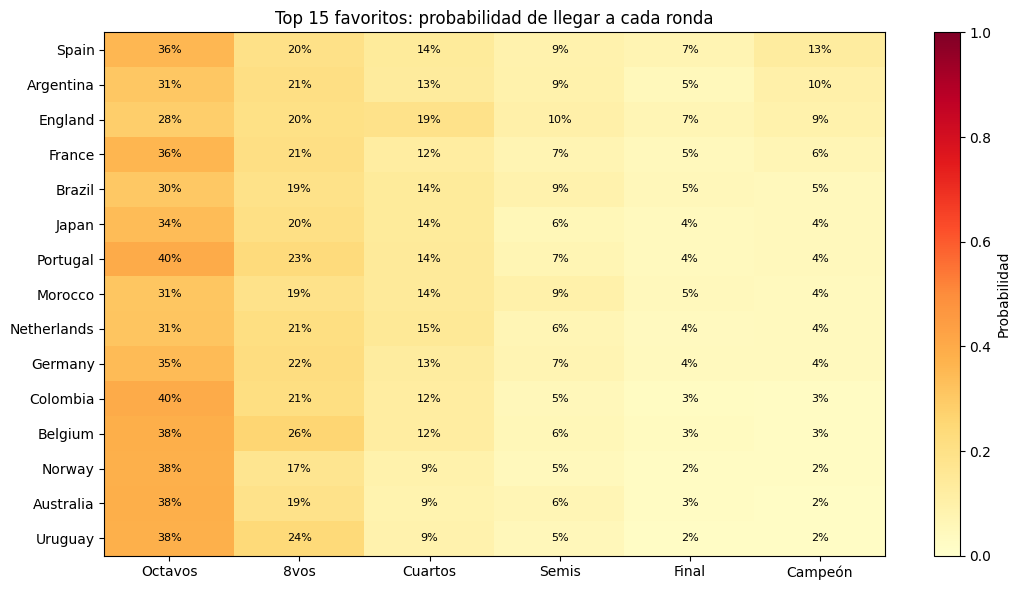

In [7]:
rounds = pd.read_csv(OUTPUTS / 'simulations' / 'round_reached_probabilities.csv')

STAGE_ORDER = ['r32', 'r16', 'qf', 'sf', 'final', 'champion']
STAGE_LABELS = {'r32': 'Octavos', 'r16': '8vos', 'qf': 'Cuartos', 'sf': 'Semis', 'final': 'Final', 'champion': 'Campeón'}

pivot = rounds.pivot_table(index='team', columns='stage', values='prob', aggfunc='max').fillna(0)
pivot = pivot.reindex(columns=[c for c in STAGE_ORDER if c in pivot.columns])
pivot.columns = [STAGE_LABELS.get(c, c) for c in pivot.columns]

top_teams = champ.head(15)['team'].tolist()
pivot_top = pivot.loc[[t for t in top_teams if t in pivot.index]]
print('Top 15 favoritos - prob de llegar a cada ronda:')
print((pivot_top * 100).round(1).to_string())

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(pivot_top.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(pivot_top.columns)))
ax.set_xticklabels(pivot_top.columns)
ax.set_yticks(range(len(pivot_top.index)))
ax.set_yticklabels(pivot_top.index)
for i in range(len(pivot_top.index)):
    for j in range(len(pivot_top.columns)):
        v = pivot_top.values[i, j]
        if v > 0.01:
            ax.text(j, i, f'{v*100:.0f}%', ha='center', va='center', fontsize=8, color='black' if v < 0.5 else 'white')
fig.colorbar(im, label='Probabilidad')
ax.set_title('Top 15 favoritos: probabilidad de llegar a cada ronda')
plt.tight_layout()
plt.show()

## Distribución de los caminos del bracket (campeones más frecuentes)

In [8]:
paths = pd.read_csv(OUTPUTS / 'simulations' / 'bracket_paths.csv')
print(f'Total simulaciones: {len(paths)}')
print()
print('Combinaciones campeón / subcampeón más frecuentes (top 15):')
top_finals = paths.groupby(['champion', 'runner_up']).size().sort_values(ascending=False).head(15)
print(top_finals.to_string())

Total simulaciones: 2000

Combinaciones campeón / subcampeón más frecuentes (top 15):
champion   runner_up  
Spain      England        34
           Argentina      33
Argentina  Spain          30
England    Spain          27
Spain      Portugal       21
Argentina  Brazil         18
           Morocco        17
England    Morocco        17
           Brazil         16
           Japan          15
Spain      Algeria        14
Argentina  Germany        13
           Netherlands    13
France     Spain          13
Spain      Colombia       13


## Picks recomendados por perfil (preview)

In [9]:
for p in PROFILES:
    print('=' * 60)
    print(f'  PERFIL: {p.upper()}')
    print('=' * 60)
    cols = ['date', 'team_a', 'team_b', 'pick', 'confidence']
    cols = [c for c in cols if c in sheets[p].columns]
    print(sheets[p][cols].head(12).to_string(index=False))
    print()

  PERFIL: SAFE
      date        team_a             team_b pick  confidence
2026-06-11        Mexico       South Africa    H    0.575598
2026-06-12   South Korea            Czechia    H    0.750901
2026-06-12        Canada Bosnia-Herzegovina    H    0.750901
2026-06-13 United States           Paraguay    H    0.499992
2026-06-13         Qatar        Switzerland    A    0.750460
2026-06-13        Brazil            Morocco    H    0.422665
2026-06-14     Australia             Turkey    H    0.469322
2026-06-14   Netherlands              Japan    A    0.424858
2026-06-14         Haiti           Scotland    A    0.454126
2026-06-14   Ivory Coast            Ecuador    H    0.388082
2026-06-14       Germany            Curaçao    H    0.726621
2026-06-15        Sweden            Tunisia    H    0.410942

  PERFIL: BALANCED
      date        team_a             team_b pick  confidence
2026-06-11        Mexico       South Africa    H    0.557126
2026-06-12   South Korea            Czechia    H  

In [10]:
pickel = pd.read_pickle("../models/rating_ensemble.pkl")

In [11]:
print(dir(pickel))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_zscore', 'composite_table', 'elo', 'fit', 'form', 'match_counts', 'pi', 'shrinker', 'weights']


In [12]:
ratings_ordenados = sorted(
    pickel.elo.ratings.items(), 
    key=lambda item: item[1], 
    reverse=True
)

In [13]:
for i, (clave, valor) in enumerate(ratings_ordenados[:30], 1):
    print(f"{i}. {clave}: {valor}")

1. Morocco: 1681.0762896838714
2. Spain: 1679.902474264104
3. England: 1665.080466860018
4. Nigeria: 1650.6867406321294
5. Argentina: 1643.7445640311541
6. France: 1640.2579184814074
7. Senegal: 1636.4730203978802
8. Algeria: 1634.0864823012648
9. Norway: 1628.061946708031
10. Netherlands: 1627.7423760438257
11. Portugal: 1626.3020022385233
12. Turkey: 1616.3716773696292
13. Germany: 1612.9046217642729
14. Belgium: 1608.5642327835862
15. Japan: 1608.2268107470613
16. Croatia: 1601.242790667391
17. Ivory Coast: 1596.7264834187372
18. Austria: 1596.29950256139
19. Switzerland: 1594.4916645038084
20. Colombia: 1592.3262470194666
21. Italy: 1591.4676970729458
22. Brazil: 1590.9247083043601
23. Egypt: 1586.1373197369278
24. Denmark: 1585.5149520703526
25. Australia: 1582.807791750213
26. Mexico: 1579.23175424064
27. Ecuador: 1578.3120760518761
28. Iran: 1575.608846673364
29. DR Congo: 1573.6270604131819
30. Panama: 1572.8504332956736


# extras que se borrarán

In [14]:
import pickle
from src.prediction.predictor import MatchPredictor
from src.models.base_model import BaseOutcomeModel
from src.utils.io import load_pickle

ensemble = load_pickle("../models/rating_ensemble.pkl")
poisson  = load_pickle("../models/poisson_model.pkl")
elo      = ensemble.elo

predictor = MatchPredictor(
    outcome_models={},          # forza el escenario de la simulación
    poisson_model=poisson,
    elo=elo,
)

pares = [
    ("Spain", "Iraq"),
    ("Brazil", "Saudi Arabia"),
    ("France", "Panama"),
    ("Argentina", "Paraguay"),
    ("Germany", "Norway"),
    ("Paraguay", "Iraq"),       # mid vs mid
]
for a, b in pares:
    # Elo solo
    eh, ed, ea = elo.predict(a, b, neutral=True)
    # Poisson solo
    import pandas as pd
    pp = poisson.predict_proba(pd.DataFrame({"team_a":[a], "team_b":[b]}))[0]
    # Blend final
    bl = predictor.predict_single(a, b)
    print(f"{a:12s} vs {b:18s} | Elo {eh:.2f}/{ed:.2f}/{ea:.2f} | "
          f"Poi {pp[0]:.2f}/{pp[1]:.2f}/{pp[2]:.2f} | "
          f"Blend {bl.p_home:.2f}/{bl.p_draw:.2f}/{bl.p_away:.2f}")


Spain        vs Iraq               | Elo 0.53/0.23/0.25 | Poi 0.60/0.24/0.16 | Blend 0.56/0.23/0.20
Brazil       vs Saudi Arabia       | Elo 0.45/0.24/0.31 | Poi 0.62/0.21/0.17 | Blend 0.53/0.23/0.24
France       vs Panama             | Elo 0.45/0.24/0.31 | Poi 0.64/0.19/0.17 | Blend 0.54/0.22/0.24
Argentina    vs Paraguay           | Elo 0.49/0.23/0.27 | Poi 0.65/0.23/0.12 | Blend 0.57/0.23/0.19
Germany      vs Norway             | Elo 0.36/0.26/0.39 | Poi 0.49/0.22/0.29 | Blend 0.42/0.24/0.34
Paraguay     vs Iraq               | Elo 0.36/0.26/0.38 | Poi 0.37/0.31/0.32 | Blend 0.37/0.28/0.35


In [15]:
# Top 20 de Poisson attack ratings
print("--- ATTACK ---")
print(sorted(poisson.attack.items(), key=lambda x: -x[1])[:20])
print("--- DEFENSE (más bajo = mejor) ---")
print(sorted(poisson.defense.items(), key=lambda x: x[1])[:20])

--- ATTACK ---


AttributeError: 'PoissonScoreModel' object has no attribute 'attack'

In [ ]:
import pandas as pd
df = pd.read_csv("../outputs/simulations/round_reached_probabilities.csv")
print("Stages únicos:", df["stage"].unique())
print("Total filas:", len(df))
print("Filas por stage:", df.groupby("stage").size())


Stages únicos: ['r32']
Total filas: 48
Filas por stage: stage
r32    48
dtype: int64
